In [29]:
import copy
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch as th
import torch.nn.functional as F
from sklearn.metrics import average_precision_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch_geometric.nn import VGAE, GATConv, GCNConv, SAGEConv

In [30]:
# Données générées par le notebook 0_import_data (split train / val / test fait )

train_data = th.load('../data/train_data_norm.pt', weights_only=False)
val_data = th.load('../data/val_data_norm.pt', weights_only=False)
test_data = th.load('../data/test_data_norm.pt', weights_only=False)
data = th.load('../data/data.pt', weights_only=False)

# on vérifie les données chargées
print(test_data)
print(f"\nFeatures des nœuds : [longitude, latitude, population] -> {data.num_features} features")
print(f"\nFeatures des nœuds : [longitude, latitude, population] -> {train_data.num_features} features")

# Paramètres communs à toutes les expériences, cest paramètres pourront varier localement selon les besoins
HIDDEN, DIM_OUT, EPOCHS, LR = 32, 16, 300, 0.01
SEEDS = [0, 1, 2]

Data(edge_index=[2, 21676], country=[3363], city_name=[3363], x=[3363, 216], pos_edge_label=[2709], pos_edge_label_index=[2, 2709], neg_edge_label=[2709], neg_edge_label_index=[2, 2709])

Features des nœuds : [longitude, latitude, population] -> 3 features

Features des nœuds : [longitude, latitude, population] -> 216 features


In [31]:
# Définition de l'encodeur et des fonctions d'entraînement et de test pour les modèles


class Encoder(nn.Module):
    def __init__(self, dim_in, hidden_channels, dim_out, conv=GCNConv):
        super(Encoder, self).__init__()
        self.conv1 = conv(dim_in, hidden_channels)
        self.conv_mu = conv(hidden_channels, dim_out)
        self.conv_logstd = conv(hidden_channels, dim_out)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        mu = self.conv_mu(x, edge_index)
        logstd = self.conv_logstd(x, edge_index)
        return mu, logstd


def entrainer_et_tester(model, optimizer, epochs, train_data, val_data, test_data, patience=50):
    history = {"train": [], "val": []}
    meilleure_auc_val, meilleure_ap_val, meilleur_etat, meilleure_epoch = -1, None, None, None
    epochs_sans_amelioration = 0
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        z = model.encode(train_data.x, train_data.edge_index)
        loss = model.recon_loss(
            z, train_data.pos_edge_label_index, train_data.neg_edge_label_index
        ) + model.kl_loss() / train_data.num_nodes
        loss.backward()
        optimizer.step()
        history["train"].append(loss.item())

        # validation : pas de calcul de gradient mais on calcule la loss sur les données de validation
        model.eval()
        with th.no_grad():
            z_val = model.encode(val_data.x, val_data.edge_index)
            val_loss = model.recon_loss(
                z_val, val_data.pos_edge_label_index, val_data.neg_edge_label_index
            ) + model.kl_loss() / val_data.num_nodes
            history["val"].append(val_loss.item())
            auc_val, ap_val = model.test(z_val, val_data.pos_edge_label_index, val_data.neg_edge_label_index)
            if auc_val > meilleure_auc_val:
                meilleure_auc_val, meilleure_ap_val, meilleur_etat = auc_val, ap_val, copy.deepcopy(model.state_dict())
                meilleure_epoch = epoch + 1
                epochs_sans_amelioration = 0
            else:
                epochs_sans_amelioration += 1

        # early stopping : l'AUC val ne s'est pas améliorée depuis `patience` epochs
        if epochs_sans_amelioration >= patience:
            break

    # évaluation sur le test avec le meilleur modèle (choisi sur la validation)
    model.load_state_dict(meilleur_etat)
    model.eval()
    with th.no_grad():
        z_test = model.encode(test_data.x, test_data.edge_index)
        auc_test, ap_test = model.test(z_test, test_data.pos_edge_label_index, test_data.neg_edge_label_index)
    return history, auc_test, ap_test, meilleure_auc_val, meilleure_ap_val, meilleure_epoch


def lancer_experience(splits, conv=GCNConv, hidden_channels=HIDDEN, dim_out=DIM_OUT, EPOCHS=EPOCHS, LR=LR,
                      patience=50):
    # un entraînement par seed ; renvoie les résultats test, l'historique et le modèle de la première seed
    resultats, historique, modele = [], None, None
    for seed in SEEDS:
        th.manual_seed(seed)
        model = VGAE(Encoder(splits[0].num_features, hidden_channels, dim_out, conv))
        optimizer = th.optim.Adam(model.parameters(), lr=LR)
        debut = time.perf_counter()
        history, auc, ap, auc_val, ap_val, meilleure_epoch = entrainer_et_tester(
            model, optimizer, EPOCHS, *splits, patience=patience)
        temps = time.perf_counter() - debut  # temps d'entraînement + test (en secondes)
        resultats.append({"seed": seed, "AUC val": auc_val, "AP val": ap_val, "meilleure epoch": meilleure_epoch,
                          "epochs effectuées": len(history["train"]),
                          "AUC": auc, "AP": ap, "temps (s)": temps})
        if seed == SEEDS[0]:
            historique, modele = history, model
    return resultats, historique, modele


def afficher_resultats(nom, resultats):
    # AUC et AP de validation par seed (moyenne ± écart-type), meilleures epochs, epochs effectuées et temps moyen
    texte = f"{nom} :"
    for metrique in ["AUC val", "AP val"]:
        valeurs = [r[metrique] for r in resultats]
        texte += (f" {metrique} = " + ", ".join(f"{v:.4f}" for v in valeurs)
                  + f" (moyenne = {np.mean(valeurs):.4f} ± {np.std(valeurs, ddof=1):.4f}) |")
    texte += (f" meilleures epochs = {[r['meilleure epoch'] for r in resultats]}"
              + f" | epochs effectuées = {[r['epochs effectuées'] for r in resultats]}"
              + f" (moyenne = {np.mean([r['epochs effectuées'] for r in resultats]):.0f})"
              + f" | temps moyen = {np.mean([r['temps (s)'] for r in resultats]):.2f} s")
    print(texte)


In [48]:
# on définit plusieurs fonctions pour analyser les résultats

def resumer(df, colonnes):
    # moyenne et écart-type sur les seeds
    return df.groupby(colonnes, sort=False)[["AUC", "AP"]].agg(["mean", "std"]).round(4)


def tracer_barres(df, col_groupe, col_serie=None, titre="", ylim=(0.4, 1.03)):
    # barres AUC / AP (moyenne ± écart-type sur les seeds) + ligne de la baseline distance (section 1)
    if col_serie is None:
        df = df.assign(_serie="VGAE")
        col_serie = "_serie"
    stats = df.groupby([col_groupe, col_serie], sort=False)[["AUC", "AP"]].agg(["mean", "std"])
    groupes = list(dict.fromkeys(df[col_groupe]))
    series = list(dict.fromkeys(df[col_serie]))
    largeur = 0.8 / len(series)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, metrique in zip(axes, ["AUC", "AP"]):
        for i, serie in enumerate(series):
            positions = [g + (i - (len(series) - 1) / 2) * largeur for g in range(len(groupes))]
            moyennes = [stats.loc[(g, serie), (metrique, "mean")] for g in groupes]
            ecarts = [stats.loc[(g, serie), (metrique, "std")] for g in groupes]
            barres = ax.bar(positions, moyennes, largeur, yerr=ecarts, capsize=3,
                            label=serie if col_serie != "_serie" else None)
            ax.bar_label(barres, fmt="%.3f", padding=3, fontsize=7)
        #ax.axhline(baseline[metrique], color="#c62828", linestyle="--", linewidth=1, label="baseline distance")
        ax.axhline(0.5, color="black", linestyle=":", linewidth=1, label="hasard")
        ax.set_xticks(range(len(groupes)), groupes)
        ax.set_ylim(*ylim)
        ax.set_title(f"{metrique} test — {titre}")
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=6, fontsize=8)
    plt.tight_layout()
    plt.show()


def tracer_loss(historiques, titre):
    # courbes de loss train (trait plein) et validation (pointillés), échelle log
    plt.figure(figsize=(8, 4))
    for nom, history in historiques.items():
        ligne, = plt.plot(history["train"], label=f"{nom} train")
        plt.plot(history["val"], linestyle="--", color=ligne.get_color(), label=f"{nom} val")
    plt.yscale("log")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (échelle log)")
    plt.title(titre)
    plt.legend(fontsize=8)
    plt.show()


def afficher_matrice_confusion(lemodele, donnees_testees, titre):
    # eval() met le modèle en mode évaluation, désactivant certaines fonctionnalités comme le dropout et la normalisation par lot qui ne sont utilisées que pendant l'entraînement.
    lemodele.eval()
    with th.no_grad():
        # Encodage des nœuds pour obtenir leurs représentations latentes.
        z = lemodele.encode(donnees_testees.x, donnees_testees.edge_index)

        # Récupération de toutes les arêtes positives et négatives
        pos_edges = donnees_testees.pos_edge_label_index
        neg_edges = donnees_testees.neg_edge_label_index
        edges = th.cat([pos_edges, neg_edges], dim=1)

        probabilites = lemodele.decode(z, edges, sigmoid=True)
        perf = lemodele.test(z, pos_edges, neg_edges)
        predictions = (probabilites >= 0.9).long().cpu().numpy()

        vrais_labels = th.cat([
            th.ones(pos_edges.size(1), dtype=th.long),
            th.zeros(neg_edges.size(1), dtype=th.long),
        ]).numpy()

    matrice = confusion_matrix(vrais_labels, predictions, labels=[0, 1])
    print(f"\nMatrice de confusion — {titre}")
    print("Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]")
    print(matrice)
    print(f"Perf : AUC {perf[0]:.4f} (vrai_positif/faux_positif) - AP {perf[1]:.4f} ( précision/rappel )")

model_a (32 → 16) : AUC val = 0.9748, 0.9755, 0.9746 (moyenne = 0.9750 ± 0.0005) | AP val = 0.9752, 0.9758, 0.9755 (moyenne = 0.9755 ± 0.0003) | meilleures epochs = [103, 90, 111] | epochs effectuées = [153, 140, 161] (moyenne = 151) | temps moyen = 1.26 s
model_b (128 → 16) : AUC val = 0.9762, 0.9738, 0.9762 (moyenne = 0.9754 ± 0.0014) | AP val = 0.9761, 0.9753, 0.9770 (moyenne = 0.9761 ± 0.0008) | meilleures epochs = [78, 66, 61] | epochs effectuées = [128, 116, 111] (moyenne = 118) | temps moyen = 1.35 s
model_c (6 → 6) : AUC val = 0.9612, 0.9534, 0.9643 (moyenne = 0.9596 ± 0.0056) | AP val = 0.9631, 0.9542, 0.9656 (moyenne = 0.9610 ± 0.0060) | meilleures epochs = [284, 299, 224] | epochs effectuées = [300, 300, 274] (moyenne = 291) | temps moyen = 1.61 s


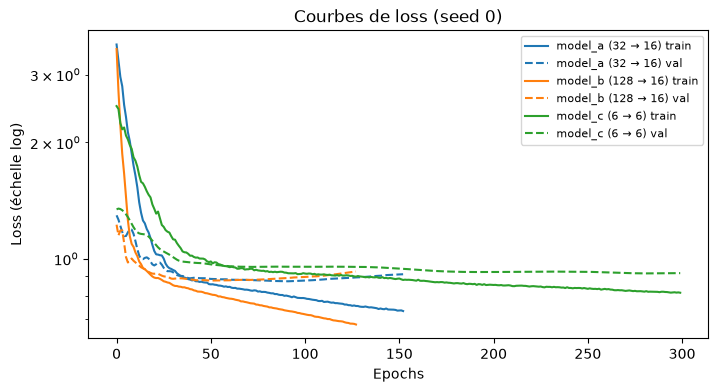

In [49]:
splits_bruts = (train_data, val_data, test_data)
dimensions = {
    "model_a (32 → 16)": (32, 16),
    "model_b (128 → 16)": (128, 16),
    "model_c (6 → 6)": (6, 6),
}

# Expérimentation sur différentes dimensions des modèles VGAE
EPOCHS_vgae=50 # le nombre d'epoch optimal a été trouvé après plusieurs tests (en comparant les performances sur la validation et le training)
resultats_dim, historiques_dim, modeles_dim = [], {}, {}
for nom, (hidden_channels, dim_out) in dimensions.items():
    resultats, historiques_dim[nom], modeles_dim[nom] = lancer_experience(
        splits_bruts, GCNConv, hidden_channels, dim_out, EPOCHS=EPOCHS, LR=LR)
    resultats_dim += [{"modele": nom, **r} for r in resultats]
    afficher_resultats(nom, resultats)

df_dimensions = pd.DataFrame(resultats_dim)

#tracer_barres(df_dimensions, "modele", titre="GCN, features brutes")
tracer_loss(historiques_dim, "Courbes de loss (seed 0)")

#for nom, model in modeles_dim.items():
    #afficher_matrice_confusion(model, val_data, f"{nom} val_data")


GCN : AUC val = 0.9748, 0.9755, 0.9746 (moyenne = 0.9750 ± 0.0005) | AP val = 0.9752, 0.9758, 0.9755 (moyenne = 0.9755 ± 0.0003) | meilleures epochs = [103, 90, 111] | epochs effectuées = [153, 140, 161] (moyenne = 151) | temps moyen = 1.28 s
GAT : AUC val = 0.9335, 0.9232, 0.9309 (moyenne = 0.9292 ± 0.0054) | AP val = 0.9270, 0.9176, 0.9119 (moyenne = 0.9188 ± 0.0076) | meilleures epochs = [95, 93, 96] | epochs effectuées = [145, 143, 146] (moyenne = 145) | temps moyen = 1.68 s
SAGE : AUC val = 0.9239, 0.9176, 0.9164 (moyenne = 0.9193 ± 0.0040) | AP val = 0.9192, 0.9038, 0.9135 (moyenne = 0.9122 ± 0.0078) | meilleures epochs = [64, 110, 83] | epochs effectuées = [114, 160, 133] (moyenne = 136) | temps moyen = 1.27 s


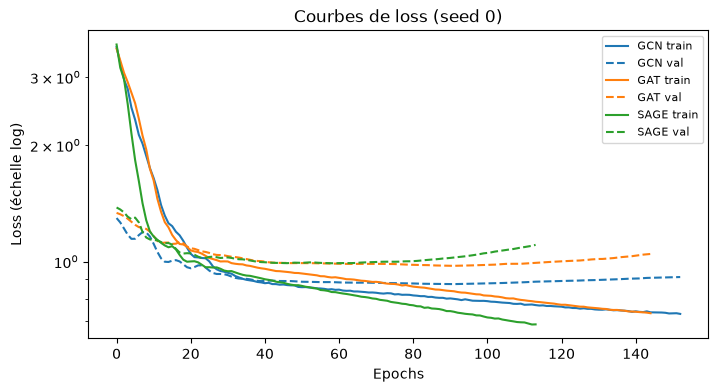

In [50]:
convs = {"GCN": GCNConv, "GAT": GATConv, "SAGE": SAGEConv}

EPOCHS_convs=30 # le nombre d'epoch optimal a été trouvé après plusieurs tests (en comparant les performances sur la validation et le training)

resultats_convs, historiques_convs, modeles_convs = [], {}, {}
for nom, conv in convs.items():
    resultats, historiques_convs[nom], modeles_convs[nom] = lancer_experience(splits_bruts, conv, EPOCHS=EPOCHS, LR=LR)
    resultats_convs += [{"couche": nom, **r} for r in resultats]
    afficher_resultats(nom, resultats)

df_convs = pd.DataFrame(resultats_convs)
#tracer_barres(df_convs, "couche", titre="features brutes")
tracer_loss(historiques_convs, "Courbes de loss (seed 0)")
#for nom, model in modeles_convs.items():
    #afficher_matrice_confusion(model, val_data, f"{nom} val_data")

In [51]:
# Recherche du learning rate sur le modèle retenu : GCNConv (32 -> 16)
# EPOCHS grand = plafond : on garde de toute façon les poids de la meilleure epoch (sur la validation)
EPOCHS_lr = 300
learning_rates = [ 0.005, 0.01, 0.05]

resultats_lr = []
for lr in learning_rates:
    resultats, _, _ = lancer_experience(splits_bruts, GCNConv, hidden_channels=32, dim_out=16, EPOCHS=EPOCHS_lr, LR=lr)
    resultats_lr += [{"LR": lr, **r} for r in resultats]
    afficher_resultats(f"LR = {lr}", resultats)



LR = 0.005 : AUC val = 0.9745, 0.9754, 0.9770 (moyenne = 0.9756 ± 0.0013) | AP val = 0.9753, 0.9762, 0.9775 (moyenne = 0.9763 ± 0.0011) | meilleures epochs = [175, 146, 211] | epochs effectuées = [225, 196, 261] (moyenne = 227) | temps moyen = 1.92 s
LR = 0.01 : AUC val = 0.9748, 0.9755, 0.9746 (moyenne = 0.9750 ± 0.0005) | AP val = 0.9752, 0.9758, 0.9755 (moyenne = 0.9755 ± 0.0003) | meilleures epochs = [103, 90, 111] | epochs effectuées = [153, 140, 161] (moyenne = 151) | temps moyen = 1.26 s
LR = 0.05 : AUC val = 0.9749, 0.9726, 0.9744 (moyenne = 0.9740 ± 0.0012) | AP val = 0.9752, 0.9724, 0.9751 (moyenne = 0.9742 ± 0.0016) | meilleures epochs = [39, 30, 49] | epochs effectuées = [89, 80, 99] (moyenne = 89) | temps moyen = 0.74 s


In [41]:
print(modeles_convs)
print(modeles_dim)


from torch import save
# sauvegarde des modèles et des résultats , comment faire ?


save(modeles_convs, "../resultats/modeles_convs.pth")

save(modeles_dim, "../resultats/modeles_dim.pth")
save(resultats_convs, "../resultats/resultats_convs.pth")
save(resultats_dim, "../resultats/resultats_dim.pth")




# on 

{'GCN': VGAE(
  (encoder): Encoder(
    (conv1): GCNConv(216, 32)
    (conv_mu): GCNConv(32, 16)
    (conv_logstd): GCNConv(32, 16)
  )
  (decoder): InnerProductDecoder()
), 'GAT': VGAE(
  (encoder): Encoder(
    (conv1): GATConv(216, 32, heads=1)
    (conv_mu): GATConv(32, 16, heads=1)
    (conv_logstd): GATConv(32, 16, heads=1)
  )
  (decoder): InnerProductDecoder()
), 'SAGE': VGAE(
  (encoder): Encoder(
    (conv1): SAGEConv(216, 32, aggr=mean)
    (conv_mu): SAGEConv(32, 16, aggr=mean)
    (conv_logstd): SAGEConv(32, 16, aggr=mean)
  )
  (decoder): InnerProductDecoder()
)}
{'model_a (32 → 16)': VGAE(
  (encoder): Encoder(
    (conv1): GCNConv(216, 32)
    (conv_mu): GCNConv(32, 16)
    (conv_logstd): GCNConv(32, 16)
  )
  (decoder): InnerProductDecoder()
), 'model_b (128 → 16)': VGAE(
  (encoder): Encoder(
    (conv1): GCNConv(216, 128)
    (conv_mu): GCNConv(128, 16)
    (conv_logstd): GCNConv(128, 16)
  )
  (decoder): InnerProductDecoder()
), 'model_c (6 → 6)': VGAE(
  (encoder):

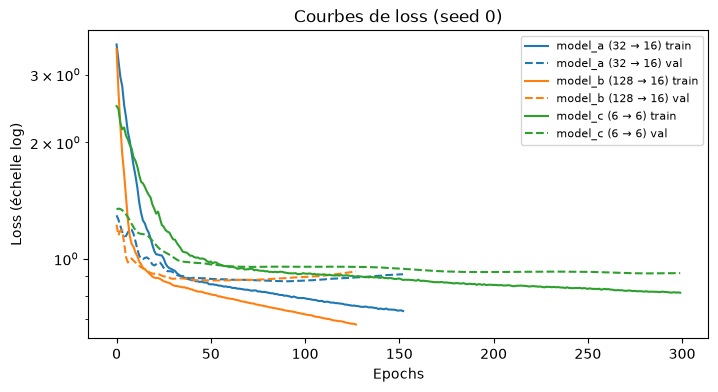

In [46]:
df_dimensions = pd.DataFrame(resultats_dim)

#tracer_barres(df_dimensions, "modele", titre="GCN, features brutes")
tracer_loss(historiques_dim, "Courbes de loss (seed 0)")

#for nom, model in modeles_dim.items():
    #afficher_matrice_confusion(model, val_data, f"{nom} val_data")



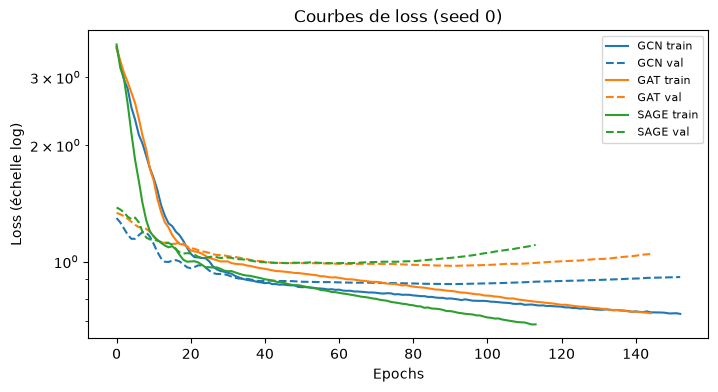

In [47]:
# on affiche les résultats pour conv

df_convs = pd.DataFrame(resultats_convs)
#tracer_barres(df_convs, "couche", titre="features brutes")
tracer_loss(historiques_convs, "Courbes de loss (seed 0)")
#for nom, model in modeles_convs.items():
    #afficher_matrice_confusion(model, val_data, f"{nom} val_data")

In [53]:
# Modèle final : VGAE avec GCNConv (32 -> 16), LR = 0.01, early stopping (patience 50, plafond 300 epochs)
# configuration choisie sur la validation ; le test_data n'est regardé qu'ici, une seule fois
resultats_final, historique_final, final_model = lancer_experience(
    splits_bruts, GCNConv, hidden_channels=32, dim_out=16, EPOCHS=300, LR=0.01, patience=50)
afficher_resultats("final_model", resultats_final)

# performances sur le test_data (moyenne ± écart-type sur les seeds)
print("\nPerformances de final_model sur le test_data :")
for metrique in ["AUC", "AP"]:
    valeurs = [r[metrique] for r in resultats_final]
    print(f"{metrique} test = " + ", ".join(f"{v:.4f}" for v in valeurs)
          + f" (moyenne = {np.mean(valeurs):.4f} ± {np.std(valeurs, ddof=1):.4f})")

# final_model = modèle de la seed 0, avec les poids de sa meilleure epoch sur la validation
afficher_matrice_confusion(final_model, test_data, "final_model test_data")


final_model : AUC val = 0.9748, 0.9755, 0.9746 (moyenne = 0.9750 ± 0.0005) | AP val = 0.9752, 0.9758, 0.9755 (moyenne = 0.9755 ± 0.0003) | meilleures epochs = [103, 90, 111] | epochs effectuées = [153, 140, 161] (moyenne = 151) | temps moyen = 1.26 s

Performances de final_model sur le test_data :
AUC test = 0.9753, 0.9757, 0.9760 (moyenne = 0.9757 ± 0.0004)
AP test = 0.9753, 0.9753, 0.9752 (moyenne = 0.9753 ± 0.0001)

Matrice de confusion — final_model test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[2643   66]
 [ 616 2093]]
Perf : AUC 0.9753 (vrai_positif/faux_positif) - AP 0.9753 ( précision/rappel )
